In [3]:
# 필요한 라이브러리 설치 및 임포트
!pip install yfinance

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. 현대차 데이터만 가져오기 (종가 기준)
df = yf.download('005380.KS', start='2025-01-01', end='2026-09-16')

# (참고) yfinance 버전이나 구조에 따라 멀티인덱스로 나올 수 있으므로 종가(Close)만 깔끔하게 정리
if isinstance(df.columns, pd.MultiIndex):
    df = df['Close']
else:
    df = df[['Close']]

# 만약 데이터프레임 구조가 Series나 단일 컬럼 형태라면 보기 좋게 정리
if '005380.KS' in df.columns:
    price_df = pd.DataFrame(df['005380.KS'])
else:
    price_df = pd.DataFrame(df.iloc[:, 0])

price_df.columns = ['Close']

# 2. 이동평균선(Moving Average) 계산하기
# 20일 이동평균선 (한 달간의 평균)
price_df['MA20'] = price_df['Close'].rolling(window=20).mean()
# 60일 이동평균선 (약 3개월간의 평균)
price_df['MA60'] = price_df['Close'].rolling(window=60).mean()

# 데이터 상단 5줄 확인하기
display(price_df.head(25))

/tmp/ipykernel_782/3268571261.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('005380.KS', start='2025-01-01', end='2026-09-16')
[*********************100%***********************]  1 of 1 completed


,Close,MA20,MA60
Date,,,
2025-01-02,195505.093750,NaN,NaN
2025-01-03,196891.640625,NaN,NaN
2025-01-06,195505.093750,NaN,NaN
2025-01-07,195042.890625,NaN,NaN
2025-01-08,197353.828125,NaN,NaN
2025-01-09,196891.640625,NaN,NaN
2025-01-10,208908.484375,NaN,NaN
2025-01-13,203362.250000,NaN,NaN
2025-01-14,205211.000000,NaN,NaN


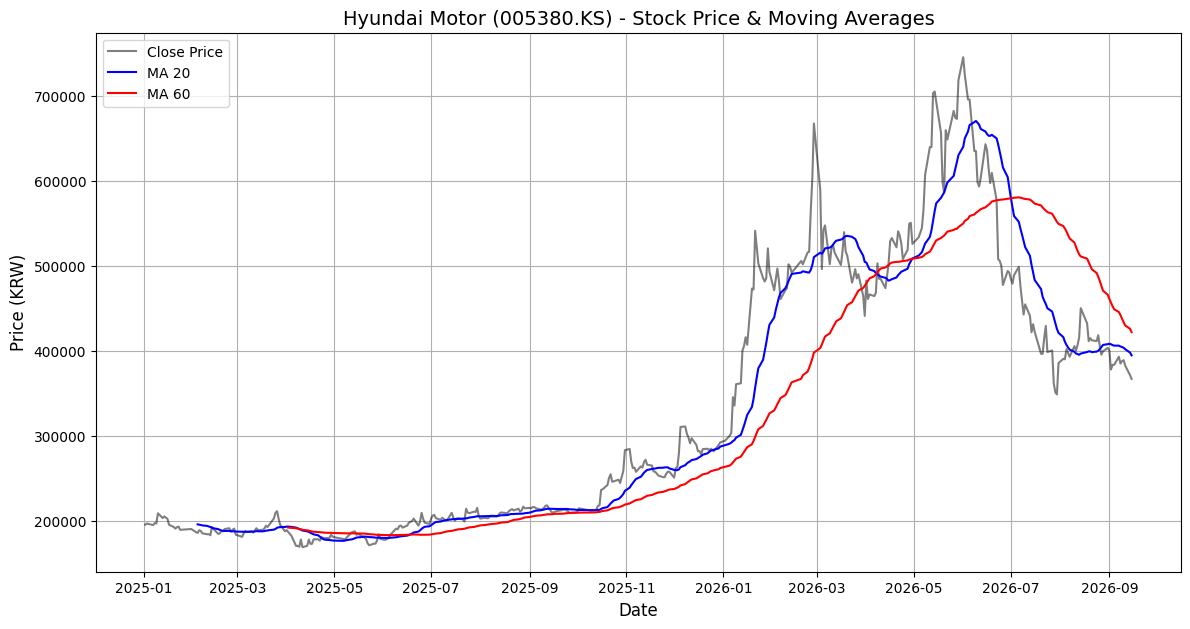

In [4]:
import matplotlib.pyplot as plt

# 그래프 크기 설정
plt.figure(figsize=(14, 7))

# 1. 실제 종가 그래프
plt.plot(price_df.index, price_df['Close'], label='Close Price', color='black', alpha=0.5)

# 2. 20일 이동평균선 (단기 추세)
plt.plot(price_df.index, price_df['MA20'], label='MA 20', color='blue', linewidth=1.5)

# 3. 60일 이동평균선 (중기 추세)
plt.plot(price_df.index, price_df['MA60'], label='MA 60', color='red', linewidth=1.5)

# 그래프 제목, 축 이름, 범례, 격자 설정
plt.title('Hyundai Motor (005380.KS) - Stock Price & Moving Averages', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (KRW)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True)

# 그래프 출력
plt.show()

In [5]:
# 1. 일일 수익률(Daily Return) 계산 (%) : 전일 대비 주가 변화율
price_df['Daily_Return'] = price_df['Close'].pct_change() * 100

# 2. 기간 중 최고가, 최저가 찾기
max_price = price_df['Close'].max()
min_price = price_df['Close'].min()

# 3. 기간 동안의 누적 수익률 계산 (시작일 대비 마지막일 기준)
start_price = price_df['Close'].iloc[0]
end_price = price_df['Close'].iloc[-1]
total_return = ((end_price - start_price) / start_price) * 100

# 4. 결과 출력하기
print("=" * 40)
print(f"🚗 현대차(005380.KS) 분석 결과 리포트")
print("=" * 40)
print(f"- 분석 기간 시작가: {start_price:,.0f} 원")
print(f"- 분석 기간 종가(최신): {end_price:,.0f} 원")
print(f"- 기간 중 최고가: {max_price:,.0f} 원")
print(f"- 기간 중 최저가: {min_price:,.0f} 원")
print(f"- 기간 총 누적 수익률: {total_return:.2f}%")
print("=" * 40)

# 데이터 상단 5줄에 일일 수익률이 잘 들어갔는지 확인
display(price_df.head())

🚗 현대차(005380.KS) 분석 결과 리포트
- 분석 기간 시작가: 195,505 원
- 분석 기간 종가(최신): 367,000 원
- 기간 중 최고가: 745,289 원
- 기간 중 최저가: 169,023 원
- 기간 총 누적 수익률: 87.72%


,Close,MA20,MA60,Daily_Return
Date,,,,
2025-01-02,195505.093750,NaN,NaN,NaN
2025-01-03,196891.640625,NaN,NaN,0.709213
2025-01-06,195505.093750,NaN,NaN,-0.704218
2025-01-07,195042.890625,NaN,NaN,-0.236415
2025-01-08,197353.828125,NaN,NaN,1.184836


In [7]:
import numpy as np

# 데이터 복사
adv_df = price_df.copy()

# 1. 추가 기술적 지표 만들기
# (1) 고가와 저가의 차이 (일일 변동 폭)
adv_df['Price_Range'] = adv_df['High'] - adv_df['Low'] if 'High' in adv_df.columns and 'Low' in adv_df.columns else 0

# (2) 이동평균 괴리율 (현재 주가와 20일 이동평균선의 차이 %)
adv_df['Disparity_20'] = (adv_df['Close'] / adv_df['MA20']) * 100

# (3) 간단한 RSI 계산 함수 적용 (14일 기준)
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

adv_df['RSI'] = calculate_rsi(adv_df['Close'])

# 2. 타겟 변수 및 결측치 처리
adv_df['Target'] = (adv_df['Close'].shift(-1) > adv_df['Close']).astype(int)
adv_df = adv_df.dropna()

# 3. 학습에 사용할 피처(X)와 정답(y) 재설정
X_adv = adv_df[['Close', 'MA20', 'MA60', 'Daily_Return', 'Disparity_20', 'RSI']]
y_adv = adv_df['Target']

# 4. 데이터 분할 및 모델 재학습 (랜덤 포레스트)
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(X_adv, y_adv, test_size=0.2, shuffle=False)

model_adv = RandomForestClassifier(n_estimators=100, random_state=42)
model_adv.fit(X_train_adv, y_train_adv)

# 5. 성능 평가
y_pred_adv = model_adv.predict(X_test_adv)
new_accuracy = accuracy_score(y_test_adv, y_pred_adv)

print("=" * 40)
print(f"🚀 기술적 지표가 추가된 현대차 주가 예측 모델 결과")
print("=" * 40)
print(f"- 기존 모델 정확도: 43.66%")
print(f"- 고도화 모델 정확도(Accuracy): {new_accuracy * 100:.2f}%")
print("=" * 40)

🚀 기술적 지표가 추가된 현대차 주가 예측 모델 결과
- 기존 모델 정확도: 43.66%
- 고도화 모델 정확도(Accuracy): 46.48%
